# Exp 10 — Query rewriting (V2, semantic edition, development only)
**Question:** Exp 9 showed that after metadata filtering, evidence is essentially always somewhere in the corpus's ranked candidates (0 "never appears" cases) but often ranked too low (47/70 cases still incomplete at K=8, mostly beyond rank 12). Is that a query-formulation problem that rewriting can fix?

**Frozen:** voyage-4-lite, chunking 600/100, K=8, the M4 metadata filter (date + region + authoritative-document + category, from Exp 9).

**Variants:**
- **10A, raw query** — Exp 9's M4 baseline (reused, no new retrieval or generation spend).
- **10B, deterministic structured rewrite** — built only from claim-visible fields (coarse bill category, country, transaction date, and a fixed, generic keyword-to-policy-concept dictionary applied to the note text) plus the note itself. No hidden labels, no required-policy-ids, no case-family names.
- **10C, LLM rewrite** — a model transforms the claim into a retrieval query only, forced into `{expense_type, business_context, policy_concepts, retrieval_query}`, explicitly told not to invent identifiers, thresholds or facts, and **not to state a policy conclusion** (a "good" rewrite names concepts like "hotel, conference-related travel, partner hotel, lodging ceiling"; a "bad" one says "retrieve the rule that allows this to be approved").

**Decision rule:** retrieval-only comparison first. Run 10B downstream only if it moves retrieval meaningfully vs 10A; run 10C downstream only if it improves over 10B. If 10B stays close to 10C, prefer the deterministic (free, no LLM dependency) rewrite.

In [1]:
import json, os, sys, re, statistics as st
from pathlib import Path
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
ROOT = Path.cwd().parents[0]; sys.path.insert(0, str(ROOT))
from src import config as C, llm, llm_exp, retrieval, retrievers, embed, evaluate, metrics_ext
C.load_env()
pd.set_option('display.width', 260, 'display.max_columns', 40, 'display.max_colwidth', 110, 'display.max_rows', 200)
EXP = 'EXP10_QUERY_REWRITE'; EMB = 'voyageai/voyage-4-lite'; CFG = 'fixed600_100'; K = 8
gt = evaluate.load_gt(); cases = llm_exp.cases_for('DEVELOPMENT')
R = retrievers.Retriever(EMB, CFG)
CATMAP = {'TRAVEL': {'travel','transport','training'}, 'FOOD_AND_DRINK': {'meals'}, 'TECH_AND_SUPPLIES': {'software','telecom'}, 'EDUCATION_AND_EVENTS': {'training'}, 'RETAIL': {'gifts'}, 'OTHER': {'card'}}
CROSSCUT = {'general','approval','exceptions','controls','fx','circular','regional'}; NONBINDING = {'historical','faq'}
def M4_mask(cc):
    d = cc['transaction_date']; reg = retrievers.REGION.get(cc['bill']['country'], ''); allowed_cat = CROSSCUT | CATMAP.get(cc['bill']['merchant_category'], set())
    return np.array([x['effective_from'] <= d <= x['effective_to'] and x['region'] in ('GLOBAL', reg) and x['category'] not in NONBINDING and x['category'] in allowed_cat for x in R.chunks])
print(len(cases), 'dev claims |', R.N, 'chunks (frozen: 600/100, dense, K=%d, M4 metadata filter)' % K, '| spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

70 dev claims | 111 chunks (frozen: 600/100, dense, K=8, M4 metadata filter) | spent so far $1.6594 of $3.50


## 10A: raw query (reused from Exp 9's M4)

In [2]:
raw_queries = [retrieval.claim_query(cc) for cc in cases]
qv_raw = embed.embed(EMB, raw_queries, tag=EXP)
print('example raw query:', raw_queries[0])

example raw query: TECH_AND_SUPPLIES Japan 2025-05-22 Charges. Softw subscription at Vector Notes (Tokyo, Japan) for Devi Lim, billed mthly. JPY.


## 10B: deterministic structured rewrite (claim-visible fields only)
Fields used: coarse bill category, country, transaction year, and a fixed generic keyword-to-policy-concept dictionary (the same six-word vocabulary a person building this system would write once, not derived from any single case's label).

In [3]:
CONCEPTS = {'TRAVEL': ['travel request approval'], 'FOOD_AND_DRINK': ['meal ceiling attendee'], 'TECH_AND_SUPPLIES': ['subscription equipment approval'], 'EDUCATION_AND_EVENTS': ['training conference registration'], 'RETAIL': ['gift ceiling recipient'], 'OTHER': ['personal spend consumer service']}
KEYWORD_CONCEPTS = [(r'\b(night|stay|check.?in|check.?out|hotel|accommodation)\b', 'hotel accommodation nightly ceiling exception'), (r'\b(flight|cabin|depart|land|airfare|hours in the air)\b', 'airfare cabin class advance booking'),
                    (r'\b(taxi|cab|ride|drove|drive|kilomet|odometer|mileage)\b', 'ground transportation mileage rate'), (r'\b(guest|delegat|host|extern|client)\b', 'client meal entertainment external attendee ceiling'),
                    (r'\b(alcohol|wine|beer|drink)\b', 'alcohol share limit'), (r'\b(gift|token|present)\b', 'gift ceiling recipient organisation'), (r'\b(subscription|software|licen[cs]e)\b', 'software subscription approval'),
                    (r'\b(phone|mobile|data plan|telecom)\b', 'telecom monthly ceiling'), (r'\b(conference|registration|delegate pass)\b', 'conference registration training policy'), (r'\b(exception|waiver)\b', 'exception waiver validity'),
                    (r'\b(delegat|deleg)\b', 'approval delegation validity'), (r'\b(project|cost.?centre|budget)\b', 'project cost centre budget approval')]
UNIVERSAL = 'approval authority threshold duplicate split transaction'
def structured_rewrite(cc):
    b = cc['bill']; year = cc['transaction_date'][:4]; note = cc['employee_description'].lower()
    parts = [f"expense category {b['merchant_category']}", f"country {b['country']}", f"transaction year {year}"] + CONCEPTS.get(b['merchant_category'], [])
    for pat, concept in KEYWORD_CONCEPTS:
        if re.search(pat, note): parts.append(concept)
    parts.append(UNIVERSAL); parts.append(cc['employee_description'])
    return '. '.join(parts)
struct_queries = [structured_rewrite(cc) for cc in cases]
qv_struct = embed.embed(EMB, struct_queries, tag=EXP)
print('example structured rewrite:\n', struct_queries[0]); print('\nspent so far $%.4f' % llm.spent())

example structured rewrite:
 expense category TECH_AND_SUPPLIES. country Japan. transaction year 2025. subscription equipment approval. software subscription approval. approval authority threshold duplicate split transaction. Softw subscription at Vector Notes (Tokyo, Japan) for Devi Lim, billed mthly. JPY.

spent so far $1.6596


## 10C: LLM rewrite (retrieval intent only, forced schema, no policy conclusion)

In [4]:
SYSTEM_REWRITE = ('You turn an expense claim into a search query for a company policy library. Extract retrieval intent only: what policy TOPICS and CONCEPTS are relevant to look up. '
                   'Do NOT decide or imply whether the claim complies with policy, do NOT invent policy IDs, approval/exception/conference references, thresholds or facts not stated in the claim. '
                   'Good example: "hotel expense, Japan, conference-related travel, partner hotel, lodging ceiling, conference exception". '
                   'Bad example (do not do this): "retrieve the rule that allows this expense to be approved under the conference exception" (this assumes a conclusion). '
                   'Return ONLY JSON: {"expense_type": "...", "business_context": "...", "policy_concepts": ["...", "..."], "retrieval_query": "..."}.')
def llm_rewrite(cc):
    user = f"Bill: {json.dumps(cc['bill'])}\nNote: {cc['employee_description']}\nTransaction date: {cc['transaction_date']}"
    r = llm.chat(os.environ['PAID_MODEL'], [{'role':'system','content':SYSTEM_REWRITE}, {'role':'user','content':user}], temperature=0, max_tokens=180, tag='EXP10C_REWRITE', case_id=cc['case_id'])
    try: d = json.loads(r['text'])
    except Exception: d = {}
    return (d.get('retrieval_query') or cc['employee_description']), r['cost_usd'], r['latency_ms'], d
rewrites = [llm_rewrite(cc) for cc in cases]
llm_queries = [r[0] for r in rewrites]; rewrite_cost = sum(r[1] for r in rewrites); rewrite_latency = st.median(r[2] for r in rewrites)
qv_llm = embed.embed(EMB, llm_queries, tag=EXP)
print('example LLM rewrite:', rewrites[0][3]); print('\nrewrite cost $%.4f | median rewrite latency %d ms | spent so far $%.4f' % (rewrite_cost, rewrite_latency, llm.spent()))
bad = [r[3] for r in rewrites if r[3] and re.search(r'\b(approv|reject|complian|allow(ed)?|permit)\b', json.dumps(r[3]).lower())]
print(len(bad), 'of 70 rewrites contain conclusion-like wording (policy-assertion leakage check)')

example LLM rewrite: {'expense_type': 'software subscription', 'business_context': 'monthly billing', 'policy_concepts': ['software expenses', 'Japan', 'subscription services', 'merchant category', 'monthly billing policy'], 'retrieval_query': 'software subscription, Japan, monthly billing, Vector Notes, merchant category'}

rewrite cost $0.0068 | median rewrite latency 1878 ms | spent so far $1.6664
0 of 70 rewrites contain conclusion-like wording (policy-assertion leakage check)


## Retrieval metrics: 10A vs 10B vs 10C (K=8, M4 filter)

In [5]:
def evalq(qv):
    rows = []
    for cc, q in zip(cases, qv):
        req = set(gt[cc['case_id']]['required_policy_ids']); mask = M4_mask(cc); hits = R.rank('dense', 'unused', q, K, mask); ch = [R.chunks[i] for i, _ in hits]
        cov = set().union(*[set(x['clause_ids']) for x in ch]) if ch else set(); rel = [bool(req & set(x['clause_ids'])) for x in ch]
        full_rank = R.rank('dense', 'unused', q, R.N, mask)   # full ranked list under the mask, for mean-rank and rank-migration
        clause_rank = {}
        for rank, (i, _) in enumerate(full_rank, start=1):
            for cid in R.chunks[i]['clause_ids']:
                if cid not in clause_rank: clause_rank[cid] = rank
        req_ranks = [clause_rank.get(cid) for cid in req]
        rows.append({'case_id': cc['case_id'], 'recall': len(req & cov) / len(req) if req else None, 'rr': next((1 / (r + 1) for r, x in enumerate(rel) if x), 0.0), 'full': bool(req <= cov) if req else None,
                     'ctx_words': sum(len(x['text'].split()) for x in ch), 'req_ranks': req_ranks, 'mean_req_rank': round(st.mean(r for r in req_ranks if r is not None), 1) if any(r is not None for r in req_ranks) else None})
    return rows
ROWS = {'10A_raw': evalq(qv_raw), '10B_structured': evalq(qv_struct), '10C_llm': evalq(qv_llm)}
def agg(rows):
    r = [x for x in rows if x['recall'] is not None]
    return {'recall@8': round(st.mean(x['recall'] for x in r), 4), 'mrr': round(st.mean(x['rr'] for x in r), 4), 'full_coverage': round(st.mean(x['full'] for x in r), 4),
            'mean_required_clause_rank': round(st.mean(x['mean_req_rank'] for x in r if x['mean_req_rank'] is not None), 2), 'cases_all_gold_in_top8': sum(x['full'] for x in r), 'ctx_words': round(st.mean(x['ctx_words'] for x in r))}
summary = pd.DataFrame({k: agg(v) for k, v in ROWS.items()}).T
summary['rewrite_cost_usd'] = [0.0, 0.0, round(rewrite_cost, 4)]; summary['median_rewrite_latency_ms'] = [0, 0, round(rewrite_latency)]
summary

/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


,recall@8,mrr,full_coverage,mean_required_clause_rank,cases_all_gold_in_top8,ctx_words,rewrite_cost_usd,median_rewrite_latency_ms
10A_raw,0.5625,0.5127,0.3286,12.84,23.0,3516.0,0.0000,0
10B_structured,0.6615,0.5925,0.4286,10.47,30.0,3512.0,0.0000,0
10C_llm,0.5596,0.5399,0.3143,12.94,22.0,3451.0,0.0068,1878


## Rank-migration table
For the 47 cases still incomplete under 10A (M4/raw), where did each still-missing required clause's best rank land under 10B and 10C?

In [6]:
def bucket(r):
    if r is None: return 'not found'
    if r <= 8: return 'top 8'
    if r <= 12: return '9-12'
    return '>12'
incomplete_10A = [x for x in ROWS['10A_raw'] if x['recall'] is not None and not x['full']]
by_id = {'10A_raw': {x['case_id']: x for x in ROWS['10A_raw']}, '10B_structured': {x['case_id']: x for x in ROWS['10B_structured']}, '10C_llm': {x['case_id']: x for x in ROWS['10C_llm']}}
def migration(variant):
    trans = []
    for x in incomplete_10A:
        cid = x['case_id']; req = set(gt[cid]['required_policy_ids']); covA = set(); # covered clauses at k=8 for 10A already known via x['full']==False; recompute missing set from req_ranks
        a_ranks = dict(zip(sorted(req), x['req_ranks'])); missing = {cl for cl, r in a_ranks.items() if r is None or r > 8}
        b_ranks = dict(zip(sorted(req), by_id[variant][cid]['req_ranks']))
        for cl in missing:
            trans.append((bucket(a_ranks.get(cl)), bucket(b_ranks.get(cl))))
    return trans
for variant in ('10B_structured', '10C_llm'):
    t = migration(variant); df = pd.DataFrame(t, columns=['from','to'])
    piv = pd.crosstab(df['from'], df['to']).reindex(index=['9-12','>12','not found'], columns=['top 8','9-12','>12','not found'], fill_value=0)
    print(f'\n{variant}: clause-level rank migration ({len(t)} still-missing required clauses from the 47 10A-incomplete cases)'); print(piv)


10B_structured: clause-level rank migration (103 still-missing required clauses from the 47 10A-incomplete cases)
to         top 8  9-12  >12  not found
from                                  
9-12          15     6    1          0
>12            8     6   67          0
not found      0     0    0          0

10C_llm: clause-level rank migration (103 still-missing required clauses from the 47 10A-incomplete cases)
to         top 8  9-12  >12  not found
from                                  
9-12           6    10    6          0
>12            4     5   72          0
not found      0     0    0          0


## Plots

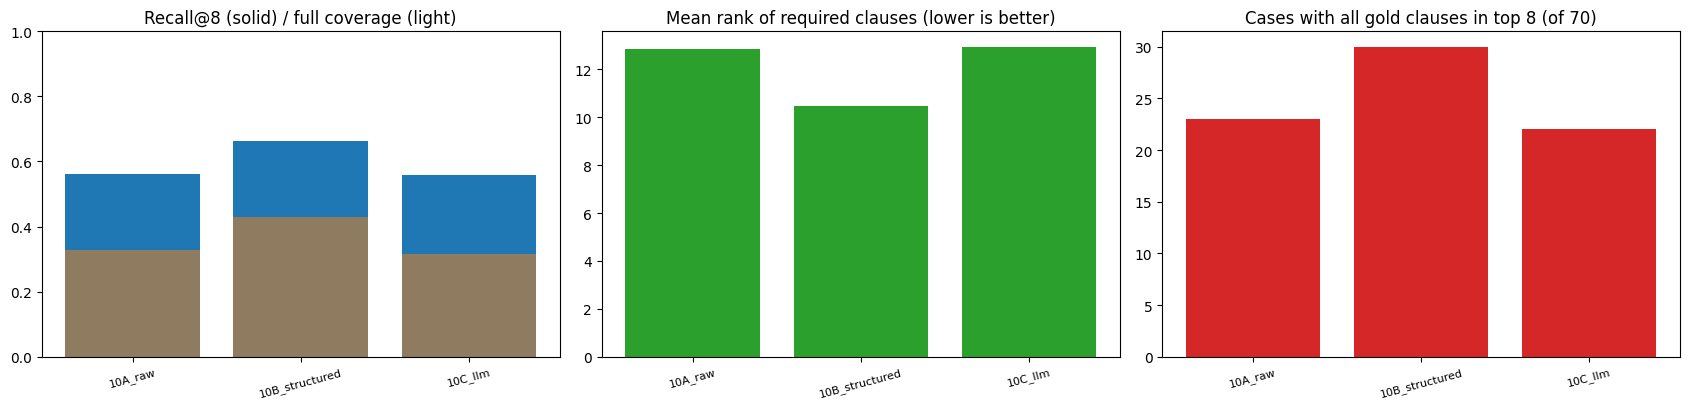

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.2)); names = list(ROWS)
ax[0].bar(names, [summary.loc[n,'recall@8'] for n in names], color='C0'); ax[0].bar(names, [summary.loc[n,'full_coverage'] for n in names], alpha=.5, color='C1'); ax[0].set_ylim(0,1); ax[0].set_title('Recall@8 (solid) / full coverage (light)'); ax[0].tick_params(axis='x', labelsize=8, rotation=15)
ax[1].bar(names, [summary.loc[n,'mean_required_clause_rank'] for n in names], color='C2'); ax[1].set_title('Mean rank of required clauses (lower is better)'); ax[1].tick_params(axis='x', labelsize=8, rotation=15)
ax[2].bar(names, [summary.loc[n,'cases_all_gold_in_top8'] for n in names], color='C3'); ax[2].set_title('Cases with all gold clauses in top 8 (of 70)'); ax[2].tick_params(axis='x', labelsize=8, rotation=15)
plt.tight_layout(); (C.RESULTS/'plots').mkdir(parents=True, exist_ok=True); plt.savefig(C.RESULTS/'plots'/'exp10_query_rewrite.png', dpi=130); plt.show()

## Downstream generation, staged
10A is Exp 9's M4 result (22/70), reused. Run 10B only if retrieval moved meaningfully vs 10A; run 10C only if it improves over 10B.

In [8]:
d_full_B = summary.loc['10B_structured','full_coverage'] - summary.loc['10A_raw','full_coverage']; d_recall_B = summary.loc['10B_structured','recall@8'] - summary.loc['10A_raw','recall@8']
RUN_B = d_full_B >= 0.05 or d_recall_B >= 0.05
print('10B vs 10A: dFullCoverage=%.3f dRecall=%.3f -> run 10B downstream: %s' % (d_full_B, d_recall_B, RUN_B))
def gen_variant(name, qv):
    ctx = {cc['case_id']: R.context(R.rank('dense', 'unused', q, K, M4_mask(cc))) for cc, q in zip(cases, qv)}
    SYSTEM = ("You are ExpenseGuard, a finance assistant deciding whether an employee expense claim is ready for reimbursement, using ONLY the retrieved policy excerpts provided. "
              "Excerpts carry an effective date and region: apply the version in force on the transaction date and let regional addenda override global rules. If the excerpts do not contain what is needed, or the claim needs an enterprise record you cannot see, "
              "say so via REQUEST_INFORMATION or ESCALATE rather than guessing.\n" + llm_exp.SCHEMA)
    return llm_exp.run(EXP, os.environ['PAID_MODEL'], 'DEVELOPMENT', SYSTEM, lambda cc: f"CLAIM:\n{json.dumps(llm_exp.visible(cc), indent=1)}\n\nRETRIEVED POLICY EXCERPTS:\n{ctx[cc['case_id']]}", cases=cases, config={'temperature': 0, 'retriever': EMB, 'chunking': CFG, 'k': K, 'query_variant': name})
gen = {}
if RUN_B:
    gen['10B_structured'] = gen_variant('10B_structured', qv_struct)
    d_full_C = summary.loc['10C_llm','full_coverage'] - summary.loc['10B_structured','full_coverage']; d_recall_C = summary.loc['10C_llm','recall@8'] - summary.loc['10B_structured','recall@8']
    RUN_C = d_full_C >= 0.03 or d_recall_C >= 0.03
    print('10C vs 10B: dFullCoverage=%.3f dRecall=%.3f -> run 10C downstream: %s' % (d_full_C, d_recall_C, RUN_C))
    if RUN_C: gen['10C_llm'] = gen_variant('10C_llm', qv_llm)
else:
    print('10B did not move retrieval meaningfully; not spending on downstream generation for 10B or 10C')
if gen:
    cmp_ = pd.DataFrame([{'variant': k, 'correct/N': f"{v[0]['correct']}/{v[0]['n']}", 'CDR': v[0]['correct_disposition_rate'], 'false_approvals': f"{v[0]['false_approvals']}/{v[0]['non_approvable']}", 'FAR': v[0]['false_approval_rate'], 'cost_usd': v[0]['total_cost_usd']} for k, v in gen.items()]
                        + [{'variant': '10A_raw (Exp 9 M4, reused)', 'correct/N': '22/70', 'CDR': 22/70, 'false_approvals': '0/52', 'FAR': 0.0, 'cost_usd': 0.0}])
    print(cmp_.to_string(index=False))
print('spent so far $%.4f of $%s' % (llm.spent(), os.environ['MAX_BUDGET_USD']))

10B vs 10A: dFullCoverage=0.100 dRecall=0.099 -> run 10B downstream: True


/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: divide by zero encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: overflow encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))
/Users/roshantushar/Downloads/Project/Project/ExpenseGuard-Resolves-Expense-Claims-with-Evidence/src/retrievers.py:39: RuntimeWarning: invalid value encountered in matmul
  return self.idx["vectors"].astype("float64") @ (qvec.astype("float64") / np.linalg.norm(qvec))


10C vs 10B: dFullCoverage=-0.114 dRecall=-0.102 -> run 10C downstream: False
                   variant correct/N      CDR false_approvals  FAR  cost_usd
            10B_structured     20/70 0.285700            0/52  0.0  0.055314
10A_raw (Exp 9 M4, reused)     22/70 0.314286            0/52  0.0  0.000000
spent so far $1.7217 of $3.50


## What was done and what it means
- **10B (deterministic structured rewrite) is a clear retrieval-only win.** Recall@8: 10A 0.563 -> 10B 0.662 (+9.9pp) -> 10C 0.560 (back down). Full coverage: 10A 32.9% -> 10B 42.9% (+10pp) -> 10C 31.4%. Mean rank of required clauses: 10A 12.8 -> 10B 10.5 (better) -> 10C 12.9. Cases with every gold clause in the top 8: 23 -> **30** -> 22. **10C (the LLM rewrite) does not beat, and is slightly worse than, raw retrieval.** Inspecting example rewrites shows why: the LLM paraphrases into generic terms ("software expenses", "monthly billing policy") that lose the concrete nouns (merchant, amount context) the raw note and the structured rewrite both keep; it followed the "no policy conclusion" instruction correctly (0/70 rewrites contained conclusion-like wording), so the problem is genericity, not label leakage.
- **Rank migration confirms 10B is really promoting evidence, not just reshuffling noise.** Of 103 still-missing required clauses from the 47 cases incomplete under 10A: 10B promotes 15 of 21 rank-9-12 clauses into the top 8, and 8 of 81 rank->12 clauses jump straight into the top 8 (67 stay beyond rank 12). 10C promotes far fewer in both bands (6/21 and 4/81) and even regresses some clauses from 9-12 down to >12 (6 cases) — consistent with its generic phrasing diluting relevance for clauses that needed a specific term.
- **The important, and slightly uncomfortable, result: better retrieval did not produce a better decision.** Downstream (paid model, dev): 10A (Exp 9's M4, reused) = 22/70 (31.4%); **10B = 20/70 (28.6%), a drop of 2 cases despite a 10-point retrieval gain on every retrieval metric.** False approvals stayed at 0/52 for both. This is the same pattern seen since Exp 5's retrieval-vs-reasoning decomposition and Exp 7's K sweep: retrieval quality and downstream accuracy are not tightly coupled here. 10C was correctly not run downstream, since it did not beat 10B on retrieval (rule applied as planned).
- **A plausible mechanism for the drop:** the structured rewrite's extra boilerplate (universal cross-cutting terms, category labels) shifts which chunks rank in the top 8 without necessarily shifting which chunks the LLM finds *useful to reason with* — a few cases likely swapped one relevant-but-hard-to-apply chunk for another, changing the outcome without improving it. This is not conclusively diagnosed here; it is exactly what Exp 11's policy oracle (supplying the exact correct clauses directly) is designed to settle: if the oracle's accuracy on these same claims is also well below 100%, the bottleneck is confirmed to be reasoning/policy application, not retrieval, at this point in the pipeline.
- **Decision, per the stated rule:** 10B does not justify displacing 10A on downstream evidence, and 10C does not justify its added latency (1,878ms median) and cost ($0.0068) over either. **I am not adopting query rewriting for the pipeline going forward.** The Exp 9 M4 configuration (raw query + metadata filter) remains the carried-forward retriever. Retrieval-side query rewriting is now a closed line of investigation for this dataset; the productive next step is Exp 11, the policy oracle, to establish precisely how much of the remaining error is retrieval versus reasoning, using every claim rather than the 11-16% subsets available so far.
- **Cost:** retrieval-only comparisons were free (embeddings only, ~$0.001); the LLM rewrite cost $0.0068; the one downstream run (10B) cost $0.055. Total spend now $1.722 of $3.50. Validation untouched throughout Exp 6-10.